# 🛡️ ZapGuard: Treino do Modelo de Deteção de Phishing
**Projeto Final: Processamento de Linguagem Natural**

Este notebook documenta o pipeline completo de treino da nossa Inteligência Artificial. Utilizaremos o **BERTimbau** (um modelo Transformer otimizado para a língua portuguesa) e aplicaremos técnicas de *Transfer Learning* (Fine-Tuning) para ensinar o modelo a classificar mensagens curtas como:
* `0` - **Seguro** (Mensagens quotidianas)
* `1` - **Fraude/Spam** (Tentativas de phishing, esquemas, etc.)

---
**Etapas do Notebook:**
1. Instalação e Configuração do Ambiente
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento e Tokenização
4. Treino da Rede Neuronal (Fine-Tuning)
5. Avaliação de Métricas e Matriz de Confusão
6. Exportação do Modelo

In [1]:
# Instala as bibliotecas necessárias para o treino e visualização
%pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
%pip install -q transformers datasets scikit-learn pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer

# Verificação de GPU — essencial para confirmar que o treino usará CUDA
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print(f"✅ GPU detectada: {torch.cuda.get_device_name(0)}")
    print(f"   Memória disponível: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
else:
    print("⚠️  Nenhuma GPU detectada — o treino rodará na CPU (mais lento).")
print(f"   Device ativo: {device}")

# Configuração de estilo para os gráficos ficarem com um aspeto moderno (padrão ZapGuard)
sns.set_theme(style="darkgrid")
colors = ["#00a884", "#ef4444"] # Verde (Seguro) e Vermelho (Fraude)
sns.set_palette(sns.color_palette(colors))
plt.rcParams['figure.figsize'] = (10, 6)

c:\Users\Leo Jaime\UFPB\P8\PLN\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ GPU detectada: NVIDIA GeForce RTX 5070
   Memória disponível: 11.9 GB
   Device ativo: cuda


## 📊 1. Análise Exploratória de Dados (EDA)
Antes de treinar o modelo, precisamos de entender o formato e a distribuição dos nossos dados. Carregaremos o nosso dataset unificado (`dataset_pt_completo.csv`) e analisaremos o balanceamento das classes e o tamanho das mensagens.

A carregar os dados...


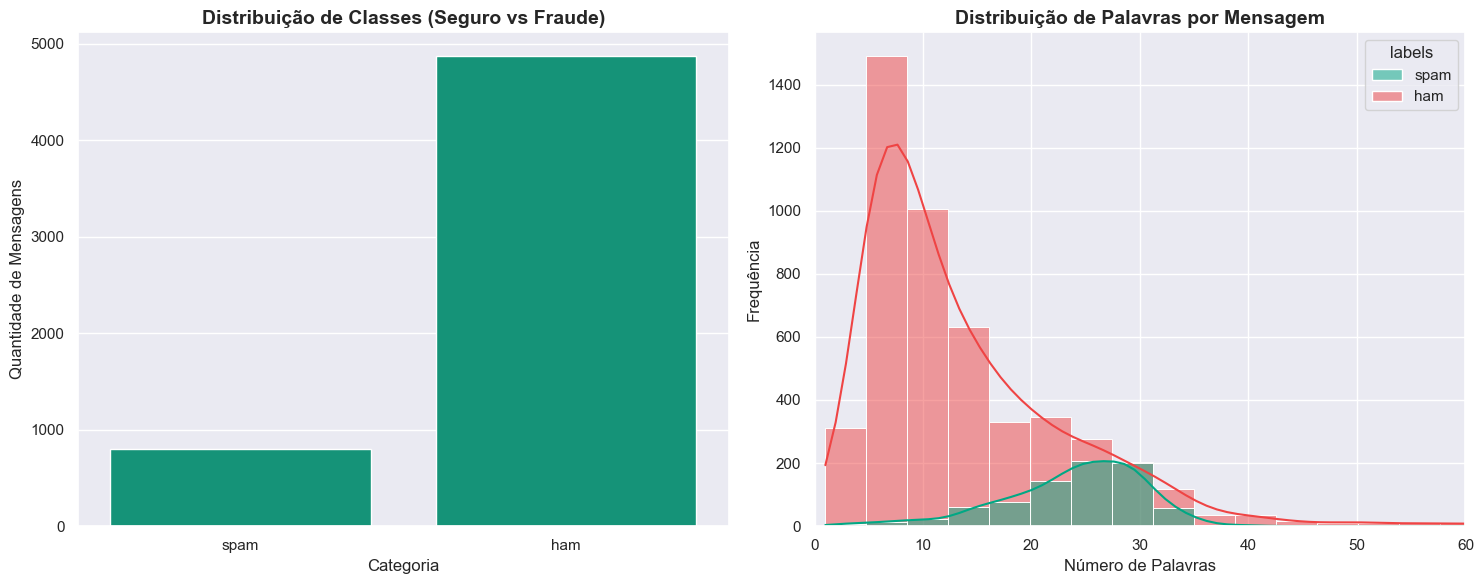

In [8]:
print("A carregar os dados...")
# O dataset está em utils/train_model/ e o notebook em utils/notebooks/
df = pd.read_csv('../train_model/dataset_pt_completo.csv')

# Remove possíveis linhas nulas
df = df.dropna(subset=['text', 'labels'])

# Calcula o tamanho de cada mensagem (em quantidade de palavras)
df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

# Criação da figura com dois subgráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Balanceamento das Classes
sns.countplot(data=df, x='labels', ax=axes[0])
axes[0].set_title('Distribuição de Classes (Seguro vs Fraude)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Quantidade de Mensagens')

# Gráfico 2: Distribuição do tamanho das mensagens
sns.histplot(data=df, x='word_count', hue='labels', bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribuição de Palavras por Mensagem', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Número de Palavras')
axes[1].set_ylabel('Frequência')
axes[1].set_xlim(0, 60)

plt.tight_layout()
plt.show()

## ⚙️ 2. Preparação dos Dados e Tokenização
Redes neuronais não leem texto, elas leem números. Nesta etapa, vamos:
1. Mapear as *labels* (`ham` para `0` e `spam` para `1`).
2. Dividir o dataset (80% para Treino, 20% para Teste).
3. Utilizar o Tokenizador do **BERTimbau** para transformar as frases em tensores matemáticos.

In [4]:
# 1. Mapeamento
df['label'] = df['labels'].map({'ham': 0, 'spam': 1})

# 2. Divisão (Train/Test Split)
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

print(f"Mensagens para Treino: {len(train_df)}")
print(f"Mensagens para Teste: {len(test_df)}")

# Converte para o formato da biblioteca 'datasets' do Hugging Face
train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

# 3. Tokenização
model_name = "neuralmind/bert-base-portuguese-cased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(examples):
    # Padding e Truncation garantem que todas as mensagens tenham o mesmo tamanho (128 tokens max)
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("\nA tokenizar os dados...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
print("Tokenização concluída!")

Mensagens para Treino: 4537
Mensagens para Teste: 1135

A tokenizar os dados...


Map: 100%|██████████| 1135/1135 [00:00<00:00, 21800.22 examples/s]

Tokenização concluída!


## 🧠 3. Fine-Tuning do BERTimbau
Aqui definimos os parâmetros da nossa rede neuronal. Como a nossa prioridade de segurança é evitar Falsos Negativos (deixar uma fraude passar), a nossa métrica principal para escolher o melhor modelo será o **Recall**.

In [5]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average='binary')
    acc = accuracy_score(labels, preds)
    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("A carregar o modelo pré-treinado...")
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=2)

training_args = TrainingArguments(
    output_dir="./zapguard_checkpoints",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="recall",
    logging_dir='./logs',
    logging_steps=50,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("A iniciar o treino...")
trainer.train()

A carregar o modelo pré-treinado...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 99530.94it/s]
BertForSequenceClassification LOAD REPORT from: neuralmind/bert-base-portuguese-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	thos

A iniciar o treino...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.036670,0.063397,0.987665,0.954839,0.980132,0.930818
2,0.020765,0.060907,0.989427,0.961538,0.980392,0.943396
3,0.005673,0.061370,0.990308,0.965079,0.974359,0.955975


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.72it/s]
There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer

TrainOutput(global_step=852, training_loss=0.03636243977740258, metrics={'train_runtime': 83.1538, 'train_samples_per_second': 163.685, 'train_steps_per_second': 10.246, 'total_flos': 895301143626240.0, 'train_loss': 0.03636243977740258, 'epoch': 3.0})

## 📈 4. Curvas de Aprendizagem e Métricas
Vamos extrair o histórico da memória do `Trainer` para visualizar como a nossa rede neuronal evoluiu ao longo das épocas (rondas) de treino. Esperamos ver o erro (Loss) a cair e a precisão a subir.

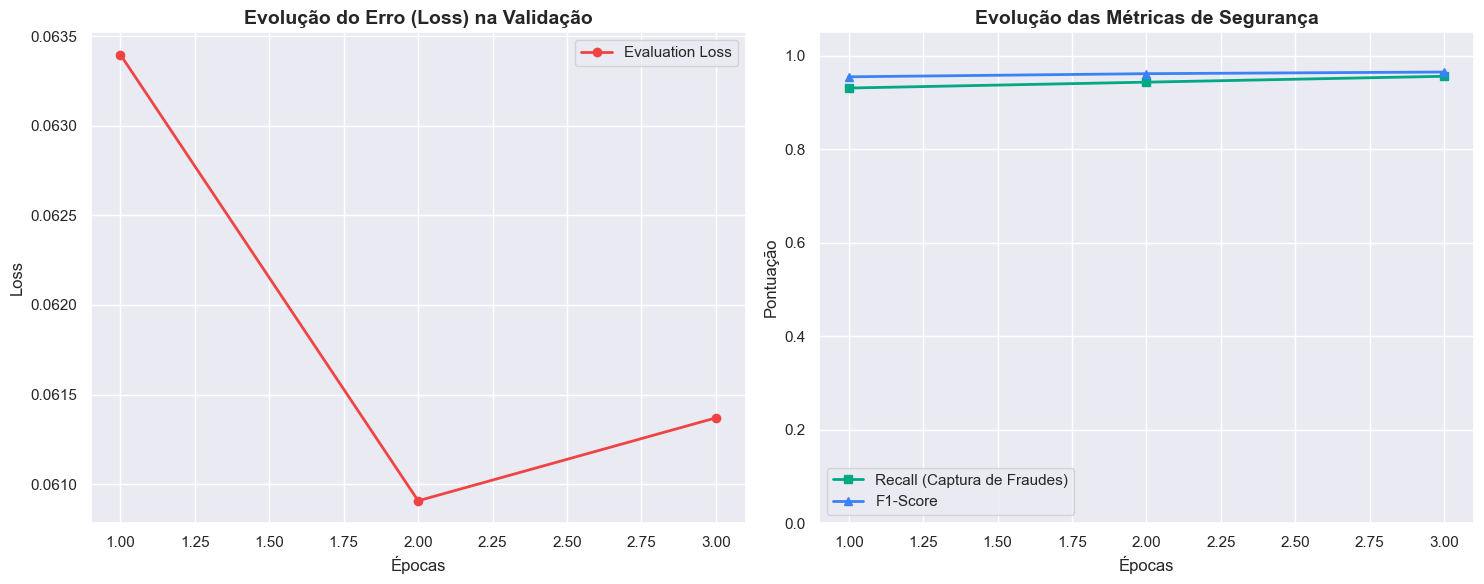

In [6]:
# Extraindo o log histórico do Trainer
history = trainer.state.log_history

# Separando dados de treino e avaliação
train_loss = [x['loss'] for x in history if 'loss' in x]
eval_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
eval_recall = [x['eval_recall'] for x in history if 'eval_recall' in x]
eval_f1 = [x['eval_f1'] for x in history if 'eval_f1' in x]

epochs_eval = range(1, len(eval_loss) + 1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Curva de Perda (Loss)
axes[0].plot(epochs_eval, eval_loss, marker='o', color='#ef4444', label='Evaluation Loss', linewidth=2)
axes[0].set_title('Evolução do Erro (Loss) na Validação', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Épocas')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Gráfico 2: Evolução das Métricas
axes[1].plot(epochs_eval, eval_recall, marker='s', color='#00a884', label='Recall (Captura de Fraudes)', linewidth=2)
axes[1].plot(epochs_eval, eval_f1, marker='^', color='#3b82f6', label='F1-Score', linewidth=2)
axes[1].set_title('Evolução das Métricas de Segurança', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Épocas')
axes[1].set_ylabel('Pontuação')
axes[1].set_ylim([0.0, 1.05]) # Foca no topo do gráfico para ver detalhes
axes[1].legend()

plt.tight_layout()
plt.show()

## 🎯 5. Matriz de Confusão e Exportação
A forma definitiva de provar a qualidade de um modelo de classificação é a Matriz de Confusão. Ela mostra-nos exatamente quantos Falsos Positivos e Falsos Negativos o modelo cometeu no dataset de teste.

A gerar previsões no conjunto de teste...


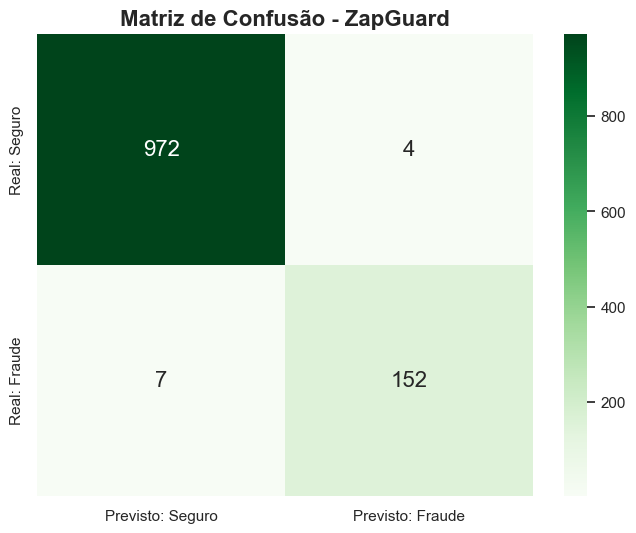

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.40it/s]


✅ Modelo finalizado e guardado na pasta: ./zapguard_model_final


In [7]:
# Realiza previsões no dataset de teste (nunca visto pelo modelo)
print("A gerar previsões no conjunto de teste...")
predictions = trainer.predict(tokenized_test)
preds_labels = predictions.predictions.argmax(-1)
true_labels = test_dataset['label']

# Calcula a matriz de confusão
cm = confusion_matrix(true_labels, preds_labels)

# Plot da Matriz de Confusão com Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Previsto: Seguro', 'Previsto: Fraude'], 
            yticklabels=['Real: Seguro', 'Real: Fraude'],
            annot_kws={"size": 16})

plt.title('Matriz de Confusão - ZapGuard', fontsize=16, fontweight='bold')
plt.show()

# Exportação do Modelo para uso na API FastAPI
final_dir = "./zapguard_model_final"
model.save_pretrained(final_dir)
tokenizer.save_pretrained(final_dir)
print(f"\n✅ Modelo finalizado e guardado na pasta: {final_dir}")

## 🔍 Interpretando a Matriz de Confusão

A Matriz de Confusão é uma tabela 2×2 que resume **todos os erros e acertos** do modelo. Leia-a assim:

|  | **Modelo disse: Seguro** | **Modelo disse: Fraude** |
|---|---|---|
| **Era Seguro (ham)** | ✅ Verdadeiro Negativo (VN) | ⚠️ Falso Positivo (FP) |
| **Era Fraude (spam)** | ❌ Falso Negativo (FN) | ✅ Verdadeiro Positivo (VP) |

---

### O que significa cada quadrante?

- **✅ Verdadeiro Negativo (VN)** — canto superior esquerdo  
  Mensagens *normais* que o modelo corretamente identificou como seguras. **Ótimo.**

- **✅ Verdadeiro Positivo (VP)** — canto inferior direito  
  Fraudes que o modelo corretamente sinalizou como perigosas. **Ótimo.**

- **⚠️ Falso Positivo (FP)** — canto superior direito  
  Mensagens normais que o modelo *achou que eram fraude*. O utilizador recebe um alerta desnecessário — chato, mas inofensivo.

- **❌ Falso Negativo (FN)** — canto inferior esquerdo  
  **O erro mais grave:** fraudes que o modelo deixou passar como seguras. É exatamente por isso que treinamos o modelo maximizando o **Recall** — para minimizar este número ao máximo.

---

### Como avaliar se o modelo foi bem?

> Um bom modelo para deteção de fraudes deve ter o quadrante **FN (Falso Negativo) o mais próximo de zero possível**, mesmo que isso signifique ter alguns FP a mais.

A fórmula do **Recall** mede justamente isso:

$$\text{Recall} = \frac{VP}{VP + FN}$$

Quanto mais próximo de **1.0 (100%)**, menos fraudes o modelo deixou escapar.

## 🔬 6. Análise dos Erros: Falsos Positivos e Falsos Negativos

Para entender *onde* o modelo errou, vamos isolar as mensagens que foram classificadas incorretamente e exibi-las lado a lado. Isso é essencial para identificar padrões de erro e oportunidades de melhoria no dataset.

In [9]:
import pandas as pd

# Reconstrói o DataFrame de teste com os textos originais
test_texts = test_df['text'].reset_index(drop=True)
test_true  = pd.Series(true_labels, name='real')
test_pred  = pd.Series(preds_labels, name='previsto')

results_df = pd.DataFrame({
    'texto':    test_texts,
    'real':     test_true.map({0: 'ham (seguro)', 1: 'spam (fraude)'}),
    'previsto': test_pred.map({0: 'ham (seguro)', 1: 'spam (fraude)'})
})

# Separa os tipos de erro
false_positives = results_df[(results_df['real'] == 'ham (seguro)')  & (results_df['previsto'] == 'spam (fraude)')].reset_index(drop=True)
false_negatives = results_df[(results_df['real'] == 'spam (fraude)') & (results_df['previsto'] == 'ham (seguro)')].reset_index(drop=True)

print("=" * 70)
print(f"⚠️  FALSOS POSITIVOS: {len(false_positives)} caso(s)")
print("    (Mensagens SEGURAS que o modelo achou que eram FRAUDE)")
print("=" * 70)
for i, row in false_positives.iterrows():
    print(f"\n[FP #{i+1}] \"{row['texto']}\"")

print("\n")
print("=" * 70)
print(f"❌  FALSOS NEGATIVOS: {len(false_negatives)} caso(s)")
print("    (Mensagens de FRAUDE que o modelo deixou passar como SEGURAS)")
print("=" * 70)
for i, row in false_negatives.iterrows():
    print(f"\n[FN #{i+1}] \"{row['texto']}\"")

print(f"\n\n📊 Resumo final:")
print(f"   Total de mensagens testadas : {len(results_df)}")
print(f"   Acertos                     : {len(results_df) - len(false_positives) - len(false_negatives)}")
print(f"   Falsos Positivos (FP)       : {len(false_positives)}")
print(f"   Falsos Negativos (FN)       : {len(false_negatives)}")
print(f"   Taxa de erro total          : {(len(false_positives) + len(false_negatives)) / len(results_df) * 100:.2f}%")

⚠️  FALSOS POSITIVOS: 4 caso(s)
    (Mensagens SEGURAS que o modelo achou que eram FRAUDE)

[FP #1] "Câmera bastante boa, 10.1mega pixels, 3optical e 5digital dooms. Tenha uma linda férias, fique seguro e espero que você tenha uma boa viagem! Feliz ano novo para vocês dois!"

[FP #2] "SORRY IM STYLE FUCKED APÓS ÚLTIMA NOITE WENT TOBED AT 430 GOT UP 4 WORK AT 630"

[FP #3] "Hey...Great deal...Farm tour 9am a 5pm $95/pax, $50 depósito até 16 de maio"

[FP #4] "Abra o rebtel com o firefox. Quando ele carrega, basta colocar mais sinal no local do nome do usuário, e ele irá mostrar-lhe dois números. O número inferior é o meu número. Uma vez que você escolher esse número, o pin será exibido bem!"


❌  FALSOS NEGATIVOS: 7 caso(s)
    (Mensagens de FRAUDE que o modelo deixou passar como SEGURAS)

[FN #1] "ROMCAPspam Todo mundo ao redor deve estar respondendo bem à sua presença, pois você é tão quente e saindo."

[FN #2] "O dinheiro que eu ganhei ganhou o número 946 do que eu faço o próximo"

[